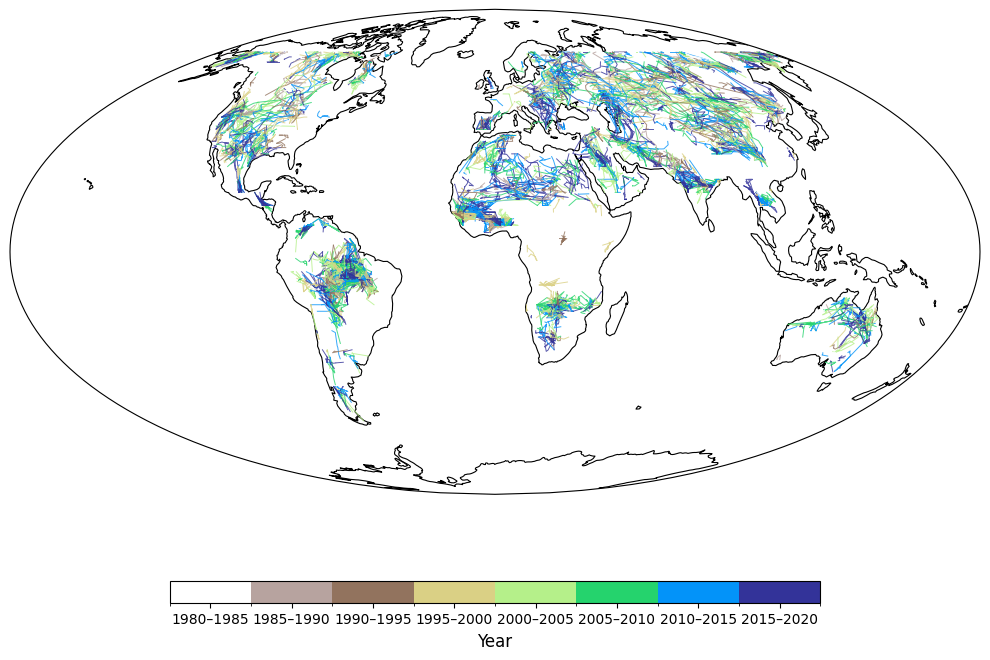

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Discrete_Terrain_Colorbar.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Discrete_Terrain_Colorbar.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Discrete_Terrain_Colorbar.svg


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Daily_Summary_CDHW_Events.xlsx"

out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Discrete_Terrain_Colorbar.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Discrete_Terrain_Colorbar.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Discrete_Terrain_Colorbar.svg"

data = pd.read_excel(file_path)

data["Date"] = pd.to_datetime(
    data["Date"],
    errors="coerce"
)

data = data.dropna(
    subset=[
        "Date",
        "Event ID",
        "Longitude",
        "Latitude"
    ]
).copy()

data["Year"] = data["Date"].dt.year

bounds = [
    1980,
    1985,
    1990,
    1995,
    2000,
    2005,
    2010,
    2015,
    2020
]

base_cmap = plt.cm.terrain_r

cmap = mcolors.ListedColormap(
    base_cmap(
        np.linspace(
            0,
            1,
            len(bounds) - 1
        )
    )
)

norm = mcolors.BoundaryNorm(
    bounds,
    cmap.N
)

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={
        "projection": ccrs.Mollweide(
            central_longitude=0
        )
    },
    facecolor="none"
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")

for event_id in data["Event ID"].unique():

    event_data = data[
        data["Event ID"] == event_id
    ].sort_values(
        by="Date"
    )

    if len(event_data) < 2:
        continue

    event_year = int(
        event_data["Year"].iloc[0]
    )

    color = cmap(
        norm(event_year)
    )

    ax.plot(
        event_data["Longitude"],
        event_data["Latitude"],
        transform=ccrs.PlateCarree(),
        linestyle="-",
        linewidth=0.7,
        alpha=0.8,
        color=color
    )

ax.coastlines(
    resolution="110m",
    linewidth=0.8
)

ax.set_global()

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    pad=0.12,
    fraction=0.03,
    aspect=30
)

cbar.set_label(
    "Year",
    fontsize=12
)

tick_positions = [
    1982.5,
    1987.5,
    1992.5,
    1997.5,
    2002.5,
    2007.5,
    2012.5,
    2017.5
]

cbar.set_ticks(
    tick_positions
)

cbar.set_ticklabels([
    "1980–1985",
    "1985–1990",
    "1990–1995",
    "1995–2000",
    "2000–2005",
    "2005–2010",
    "2010–2015",
    "2015–2020"
])

cbar.ax.tick_params(
    labelsize=10
)

plt.tight_layout()

fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

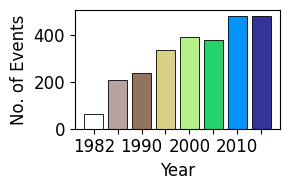

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Small_Barplot_SelectedLabels.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Small_Barplot_SelectedLabels.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Small_Barplot_SelectedLabels.svg


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Daily_Summary_CDHW_Events.xlsx"

out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Small_Barplot_SelectedLabels.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Small_Barplot_SelectedLabels.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Small_Barplot_SelectedLabels.svg"
data = pd.read_excel(file_path)

data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date", "Event ID"]).copy()
data["Year"] = data["Date"].dt.year

bounds = [1982, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]
labels = ["1982", "1985", "1990", "1995", "2000", "2005", "2010", "2015"]

data["Time Division"] = pd.cut(
    data["Year"],
    bins=bounds,
    labels=labels,
    right=False,
    include_lowest=True
)

event_counts = (
    data.groupby("Time Division", observed=False)["Event ID"]
    .nunique()
    .reindex(labels, fill_value=0)
)

base_cmap = plt.cm.terrain_r

cmap = mcolors.ListedColormap(
    base_cmap(
        np.linspace(
            0,
            1,
            len(labels)
        )
    )
)

bar_colors = [
    cmap(i)
    for i in range(len(labels))
]

fig, ax = plt.subplots(
    figsize=(3, 2),
    facecolor="none"
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")

x = np.arange(len(labels))

ax.bar(
    x,
    event_counts.values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)


ax.set_ylabel(
    "No. of Events",
    fontsize=12
)

ax.set_xlabel(
    "Year",
    fontsize=12
)

selected_labels = {
    "1982",
    "1990",
    "2000",
    "2010"
}

display_labels = [
    label if label in selected_labels else ""
    for label in labels
]

ax.set_xticks(x)

ax.set_xticklabels(
    display_labels,
    fontsize=12
)

ax.tick_params(
    axis="y",
    labelsize=12
)

ax.grid(False)

plt.tight_layout()


fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)


fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)


fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)


plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

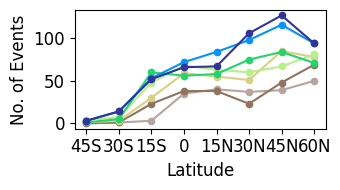

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Latitude_Variation_Small.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Latitude_Variation_Small.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Latitude_Variation_Small.svg


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Daily_Summary_CDHW_Events.xlsx"


out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Latitude_Variation_Small.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Latitude_Variation_Small.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\CDHW_Events_Latitude_Variation_Small.svg"


data = pd.read_excel(file_path)

data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date", "Latitude", "Event ID"]).copy()
data["Year"] = data["Date"].dt.year


year_bounds = [1982, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]

year_labels = [
    "1982-1985",
    "1985-1990",
    "1990-1995",
    "1995-2000",
    "2000-2005",
    "2005-2010",
    "2010-2015",
    "2015-2019"
]


data["Time Division"] = pd.cut(
    data["Year"],
    bins=year_bounds,
    labels=year_labels,
    right=False,
    include_lowest=True
)


latitude_bins = [-60, -45, -30, -15, 0, 15, 30, 45, 60]

latitude_labels = [
    "45S",
    "30S",
    "15S",
    "0",
    "15N",
    "30N",
    "45N",
    "60N"
]

data["Latitude Band"] = pd.cut(
    data["Latitude"],
    bins=latitude_bins,
    labels=latitude_labels,
    right=False,
    include_lowest=True
)

event_counts_latitude = (
    data.groupby(
        ["Time Division", "Latitude Band"],
        observed=False
    )["Event ID"]
    .nunique()
    .unstack(fill_value=0)
)

event_counts_latitude = event_counts_latitude.reindex(
    index=year_labels,
    columns=latitude_labels,
    fill_value=0
)

cmap = plt.cm.terrain_r

colors = cmap(
    np.linspace(
        0,
        1,
        len(year_labels)
    )
)

fig, ax = plt.subplots(
    figsize=(3.5, 2),
    facecolor="none"
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")


for i, time_division in enumerate(year_labels):

    ax.plot(
        latitude_labels,
        event_counts_latitude.loc[time_division].values,
        marker="o",
        markersize=4.5,
        linewidth=1.5,
        color=colors[i],
        label=time_division
    )


ax.set_xlabel(
    "Latitude",
    fontsize=12
)

ax.set_ylabel(
    "No. of Events",
    fontsize=12
)


ax.tick_params(
    axis="x",
    labelsize=12
)

ax.tick_params(
    axis="y",
    labelsize=12
)

ax.grid(False)


plt.tight_layout()


fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)


fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)


fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)


plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

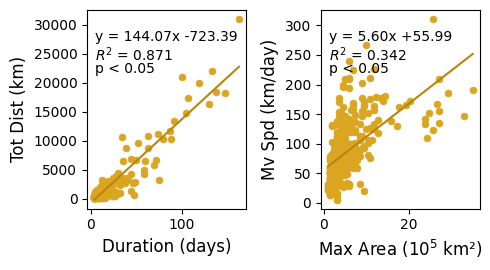

Saved: South America
PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\South_America_regression_plots_vibrant.png
PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\South_America_regression_plots_vibrant.pdf
SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\South_America_regression_plots_vibrant.svg


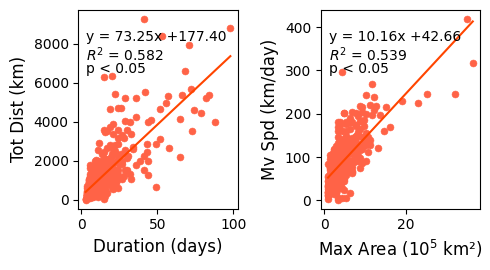

Saved: Africa
PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Africa_regression_plots_vibrant.png
PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Africa_regression_plots_vibrant.pdf
SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Africa_regression_plots_vibrant.svg


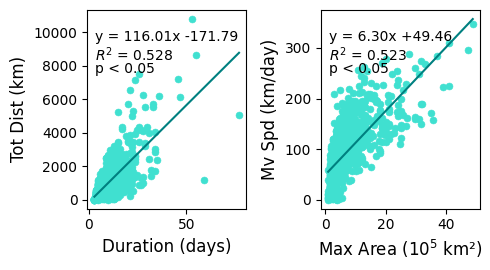

Saved: Eurasia
PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Eurasia_regression_plots_vibrant.png
PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Eurasia_regression_plots_vibrant.pdf
SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Eurasia_regression_plots_vibrant.svg


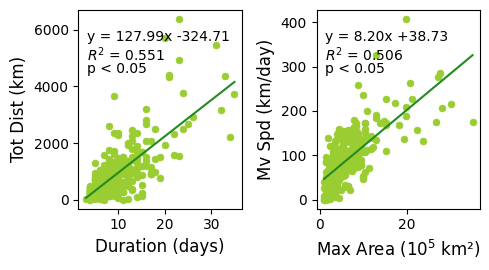

Saved: North America
PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\North_America_regression_plots_vibrant.png
PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\North_America_regression_plots_vibrant.pdf
SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\North_America_regression_plots_vibrant.svg


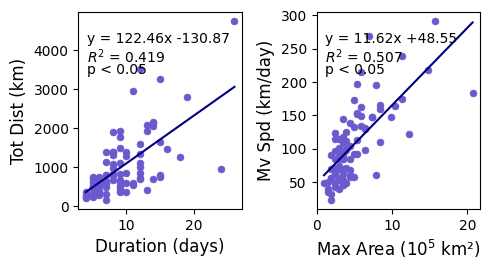

Saved: Oceania
PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Oceania_regression_plots_vibrant.png
PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Oceania_regression_plots_vibrant.pdf
SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Oceania_regression_plots_vibrant.svg


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Temporal_Events_Summary.xlsx"

output_folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots"
os.makedirs(output_folder, exist_ok=True)

data = pd.read_excel(file_path)


continent_colors = {
    "South America": ("goldenrod", "darkgoldenrod"),
    "Africa": ("tomato", "orangered"),
    "Eurasia": ("turquoise", "teal"),
    "North America": ("yellowgreen", "forestgreen"),
    "Oceania": ("slateblue", "navy")
}


text_positions = {
    "eq": (0.05, 0.90),
    "r2": (0.05, 0.82),
    "p": (0.05, 0.74)
}

def plot_regression(
    ax,
    df,
    x,
    y,
    xlabel,
    ylabel,
    text_position,
    point_color,
    line_color
):

    clean = df[[x, y]].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    if len(clean) < 2:
        ax.text(
            0.5,
            0.5,
            "Insufficient data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=10
        )
        return

    sns.scatterplot(
        x=x,
        y=y,
        data=clean,
        ax=ax,
        color=point_color,
        s=25,
        edgecolor=None
    )

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        clean[x],
        clean[y]
    )


    x_line = np.linspace(
        clean[x].min(),
        clean[x].max(),
        200
    )

    y_line = intercept + slope * x_line

    ax.plot(
        x_line,
        y_line,
        color=line_color,
        linewidth=1.5
    )

    equation_text = (
        f"y = {slope:.2f}x "
        f"{intercept:+.2f}"
    )

    ax.text(
        *text_position["eq"],
        equation_text,
        ha="left",
        va="top",
        transform=ax.transAxes,
        fontsize=10
    )

    ax.text(
        *text_position["r2"],
        f"$R^2$ = {r_value**2:.3f}",
        ha="left",
        va="top",
        transform=ax.transAxes,
        fontsize=10
    )

    p_text = (
        "p < 0.05"
        if p_value < 0.05
        else "p > 0.05"
    )

    ax.text(
        *text_position["p"],
        p_text,
        ha="left",
        va="top",
        transform=ax.transAxes,
        fontsize=10
    )

    ax.set_xlabel(
        xlabel,
        fontsize=12
    )

    ax.set_ylabel(
        ylabel,
        fontsize=12
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=10
    )


    ax.grid(False)


for continent in [
    "South America",
    "Africa",
    "Eurasia",
    "North America",
    "Oceania"
]:

    continent_data = data[
        data["Continent"] == continent
    ].copy()


    point_color, line_color = continent_colors[
        continent
    ]


    fig, axs = plt.subplots(
        1,
        2,
        figsize=(5, 2.8),
        facecolor="none"
    )

    fig.patch.set_alpha(0)

    for ax in axs:
        ax.patch.set_alpha(0)
        ax.set_facecolor("none")


    plot_regression(
        axs[0],
        continent_data,
        "Duration",
        "Total Distance",
        "Duration (days)",
        "Tot Dist (km)",
        text_positions,
        point_color,
        line_color
    )

    plot_regression(
        axs[1],
        continent_data,
        "Maximum_Area",
        "Moving Speed",
        "Max Area ($10^5$ km²)",
        "Mv Spd (km/day)",
        text_positions,
        point_color,
        line_color
    )


    plt.tight_layout()


    continent_name = continent.replace(
        " ",
        "_"
    )


    out_png = os.path.join(
        output_folder,
        f"{continent_name}_regression_plots_vibrant.png"
    )

    out_pdf = os.path.join(
        output_folder,
        f"{continent_name}_regression_plots_vibrant.pdf"
    )

    out_svg = os.path.join(
        output_folder,
        f"{continent_name}_regression_plots_vibrant.svg"
    )


    fig.savefig(
        out_png,
        dpi=900,
        transparent=True,
        facecolor="none",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.01
    )

    fig.savefig(
        out_pdf,
        format="pdf",
        transparent=True,
        facecolor="none",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.01
    )

    fig.savefig(
        out_svg,
        format="svg",
        transparent=True,
        facecolor="none",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.01
    )

    plt.show()
    plt.close(fig)

    print("Saved:", continent)
    print("PNG:", out_png)
    print("PDF:", out_pdf)
    print("SVG:", out_svg)